<a href="https://colab.research.google.com/github/sumedhawagh/DSPY/blob/main/SumedhaWagh_2301649_ExperimentNo_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Experiment No : 04**

**Aim :**

Learn use of maplotlib library as visualisation tool in data science pipeline to create contour plots, histograms and box plots.

**Performance :**

**Density and Contour plots**

Sometimes it is useful to display three-dimensional data in two dimensions using contours or color-coded regions.

There are three Matplotlib functions that can be helpful for this task: `plt.contour` for contour plots, `plt.contourf` for filled contour plots, and `plt.imshow` for showing images.

We will see examples of this type of plot in section below

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# A 3D function to plot

def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

A contour plot can be created with the `plt.contour` function. It takes three arguments: a grid of x values, a grid of y values, and a grid of z values.

The `x` and `y` values represent positions on the plot, and the z values will be represented by the contour levels.

Perhaps the most straightforward way to prepare such data is to use the `np.meshgrid` function, which builds two-dimensional grids from one-dimensional arrays:

In [ ]:
# x is set of 50 values between 0 and 5
# x is set of 40 values between 0 and 5

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

Now let's look at this with a standard line-only contour plot:

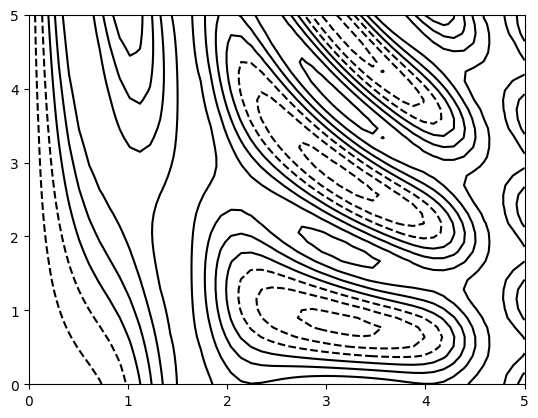

In [ ]:
plt.contour(X, Y, Z, colors='black');

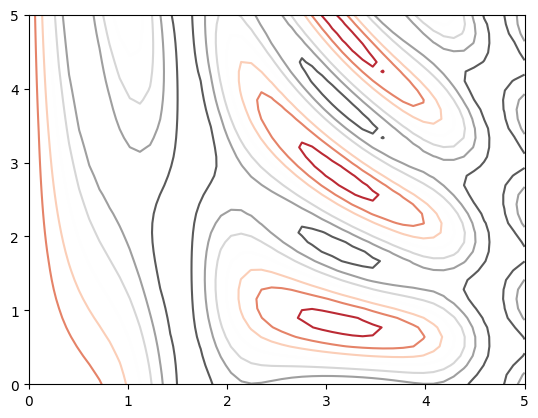

In [ ]:
plt.contour(X, Y, Z, cmap='RdGy');

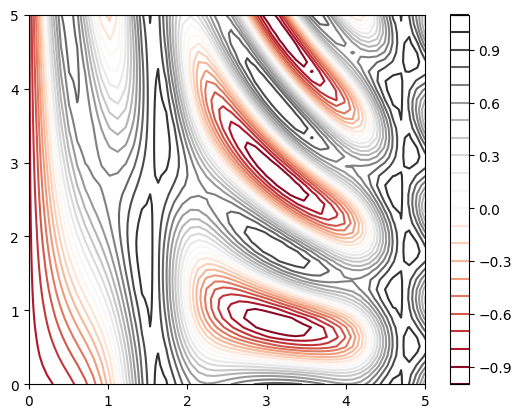

In [ ]:
plt.contour(X, Y, Z, 20, cmap='RdGy');
plt.colorbar();

Answer Following Questions :

1.Explain what are the changes you observe in contour plots above 3 code cells ?

Ans : When comparing the three contour plots:

**Number of Contour Levels Increased**

In the latest plot, 20 contour levels are used. This creates more contour lines, making the plot appear smoother and more detailed compared to plots with fewer levels.

Change in Colormap (RdGy) The colormap changes to RdGy (Red–Gray), which is a diverging colormap. This improves the visual distinction between high and low values, making variations in the data more noticeable.

Addition of Colorbar

The inclusion of plt.colorbar() adds a reference scale that shows the mapping between colors and numerical values of Z. This makes the plot easier to interpret quantitatively.

2.What is size of X, Y and Z respectively ?

Ans : The size of X, Y, and Z depends on how they were created.

In most contour plot examples, they are generated like this:

In [ ]:
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

3.How does colorbar() method help in contour plot.

Ans : The colorbar() method adds a color scale beside the contour plot that shows the relationship between colors and their corresponding numerical values. It helps in interpreting the data accurately by allowing us to determine the exact value represented by each color in the plot.

**Creating Smoother Contour Plots**

One potential issue with this plot is that it is a bit "splotchy." That is, the color steps are discrete rather than continuous, which is not always what is desired.

This could be remedied by setting the number of contours to a very high number, but this results in a rather inefficient plot: Matplotlib must render a new polygon for each step in the level. A better way to handle this is to use the `plt.imshow()` function, which interprets a two-dimensional grid of data as an image

The following code shows how to perform this:

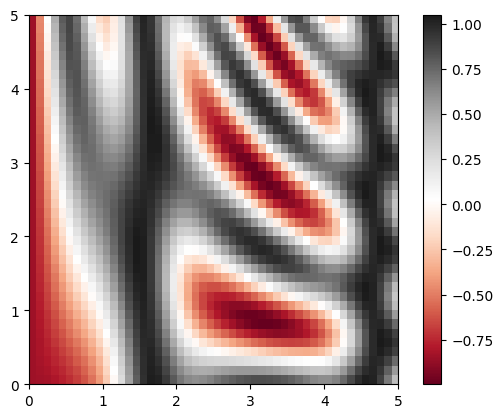

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy')
plt.colorbar()
plt.gca().set_aspect('equal', adjustable='box')

Things to remember while using imshow():

* `plt.imshow()` doesn't accept an x and y grid, so you must manually specify the extent [xmin, xmax, ymin, ymax] of the image on the plot.

* `plt.imshow()` by default follows the standard image array definition where the origin is in the upper left, not in the lower left as in most contour plots. This must be changed when showing gridded data.

* `plt.imshow()` will automatically adjust the axis aspect ratio to match the input data; this can be changed by setting, for example, `plt.axis(aspect='image')` to make x and y units match.

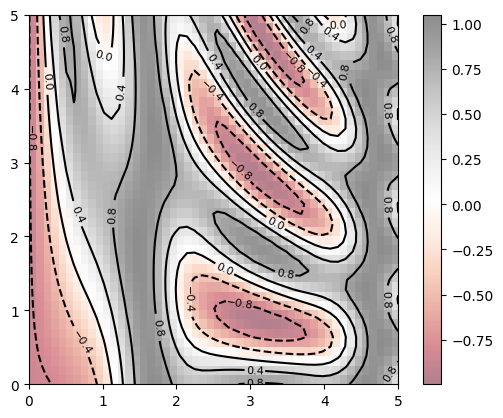

In [ ]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

Answer Following Questions :

1.What does alpha parameter do ?

Ans : The alpha parameter controls the transparency level of the plot.

alpha = 1 → completely opaque (no transparency)

alpha = 0 → completely transparent

alpha = 0.5 → semi-transparent

In the given code, alpha=0.5 makes the imshow() background partially transparent so the contour lines remain clearly visible on top of it.

2.What does clabel method does ?

Ans : The plt.clabel() method adds numerical labels to the contour lines.

It displays the corresponding Z values on each contour line.

inline=True removes part of the contour line where the label appears for better readability.

fontsize=8 sets the label text size.

This makes the contour plot easier to interpret.

3.Recreate above code block after, changing parameter 4 in contour fuction to 5 from 3. Explain what change you see in the plot.

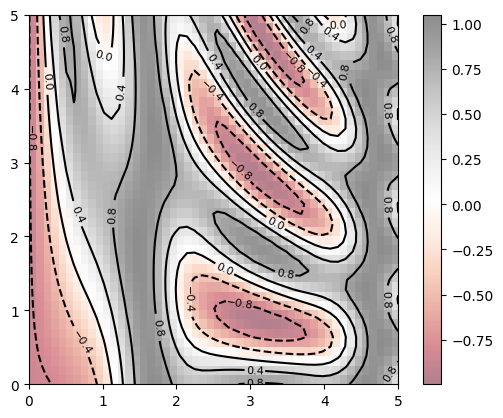

In [ ]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar()

**Histogram, Binning Plots**

A histogram is a graphical representation of a grouped frequency distribution with continuous classes. It is an area diagram and can be defined as a set of rectangles with bases along with the intervals between class boundaries and with areas proportional to frequencies in the corresponding classes. In such representations, all the rectangles are adjacent since the base covers the intervals between class boundaries. The heights of rectangles are proportional to corresponding frequencies of similar classes and for different classes, the heights will be proportional to corresponding frequency densities.

In other words, a histogram is a diagram involving rectangles whose area is proportional to the frequency of a variable and width is equal to the class interval.

The histogram graph is used under certain conditions. They are:

* The data should be numerical.
* A histogram is used to check the shape of the data distribution.
* Used to check whether the process changes from one period to another.
* Used to determine whether the output is different when it involves two or more processes.
* Used to analyse whether the given process meets the customer requirements.

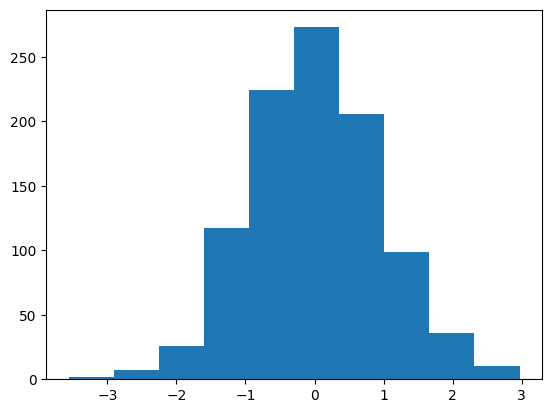

In [ ]:
# How to plot histogram
data = np.random.randn(1000)
plt.hist(data);

The `hist()` function has many options to tune both the calculation and the display; here's an example of a more customized histogram:

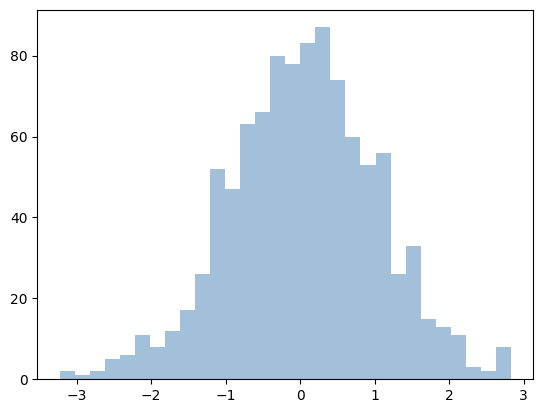

In [ ]:
plt.hist(data, bins=30, alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='none');

The `plt.hist` docstring has more information on other customization options available. I find this combination of `histtype='stepfilled'` along with some transparency `alpha` to be very useful when comparing histograms of several distributions:

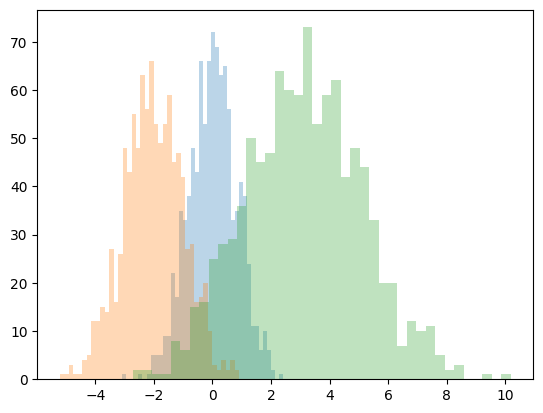

In [ ]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

If you would like to simply compute the histogram (that is, count the number of points in a given bin) and not display it, the `np.histogram()` function is available:

In [ ]:
#Only storing histogram bin frequencies without ploting it
counts, bin_edges = np.histogram(data, bins=5)
print(counts,bin_edges)

[ 27 162 457 302  52] [-3.22525144 -2.01458629 -0.80392115  0.40674399  1.61740914  2.82807428]


**`plt.hist2d`: Two-dimensional histogram**

One straightforward way to plot a two-dimensional histogram is to use Matplotlib's `plt.hist2d` function:

In [ ]:
# Create 2 Variable normally distributed data sets with 10000
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T

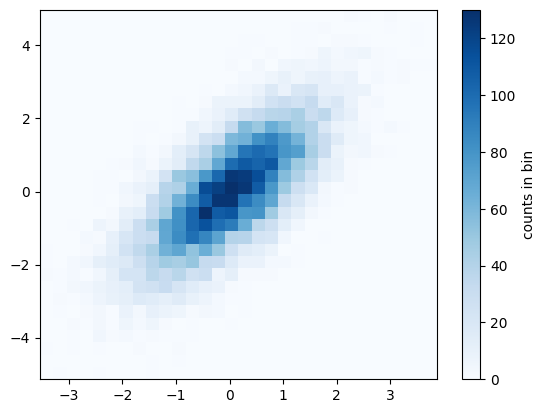

In [ ]:
#Using 2d Histogram plot
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')

Just as with `plt.hist`, `plt.hist2d` has a number of extra options to fine-tune the plot and the binning, which are nicely outlined in the function docstring. Further, just as `plt.hist` has a counterpart in `np.histogram`, `plt.hist2d` has a counterpart in `np.histogram2d`, which can be used as follows:

In [ ]:
counts, xedges, yedges = np.histogram2d(x, y, bins=30)

**`plt.hexbin`: Hexagonal binnings**

The two-dimensional histogram creates a tesselation of squares across the axes. Another natural shape for such a tesselation is the regular hexagon. For this purpose, Matplotlib provides the `plt.hexbin` routine, which will represents a two-dimensional dataset binned within a grid of hexagons:

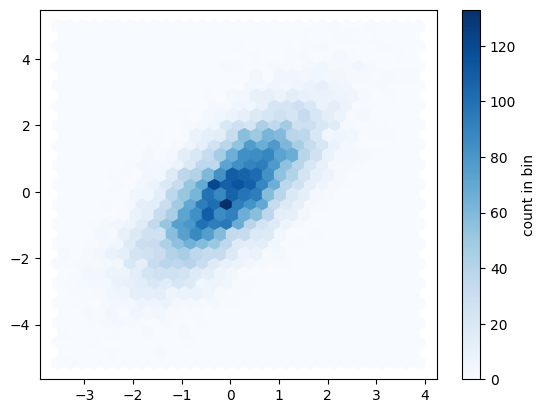

In [ ]:
plt.hexbin(x, y, gridsize=30, cmap='Blues')
cb = plt.colorbar(label='count in bin')

Questions:

1.What is role of bins parameter in histogram plot?

Ans : The bins parameter in a histogram determines how the data range is divided:

* Each bin represents an interval of values.

* The height of each bin shows how many data points fall into that interval.

* More bins → more detailed representation, but can become noisy.

* Fewer bins → smoother view, but may hide details.

2.Create a set of 10000 uniform random samples and store it in variable named norm_data. Draw histograms of norm_data with following bin counts 5, 50, 500, 5000.

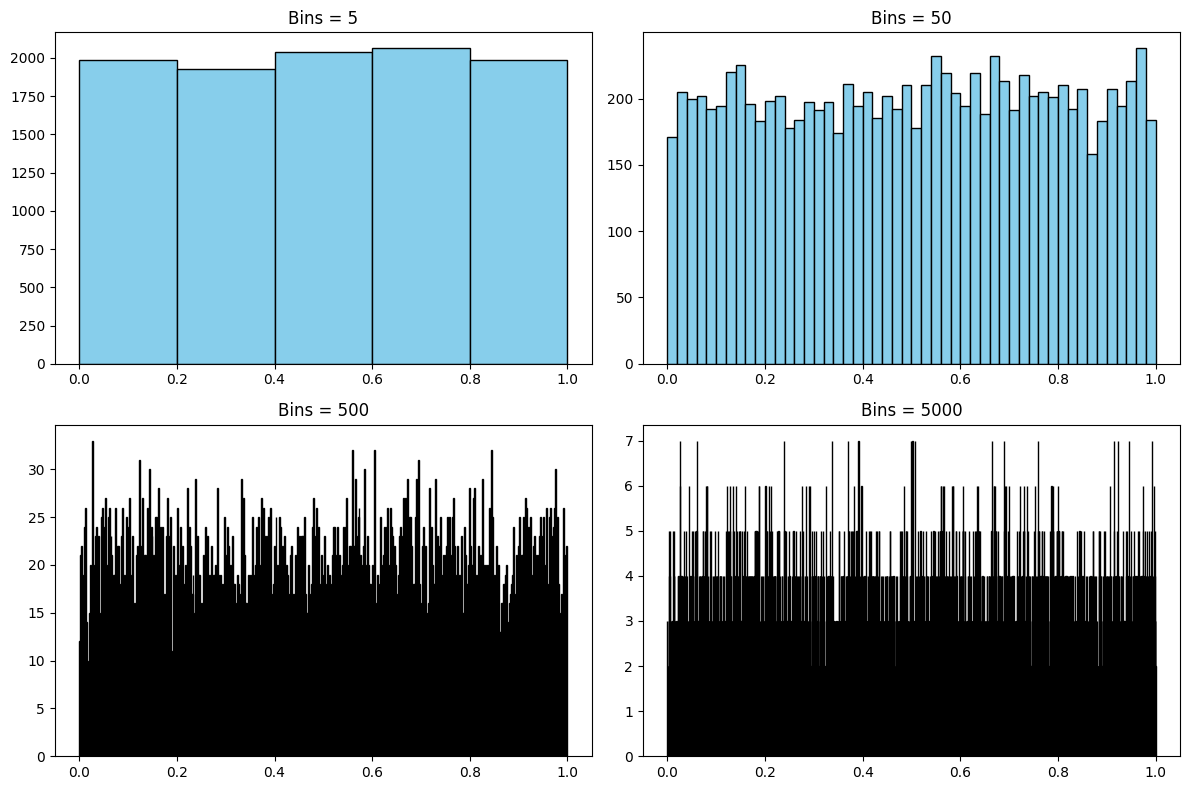

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 10000 uniform random samples
norm_data = np.random.uniform(0, 1, 10000)

# Set up figure
plt.figure(figsize=(12, 8))

# Histogram with 5 bins
plt.subplot(2, 2, 1)
plt.hist(norm_data, bins=5, color='skyblue', edgecolor='black')
plt.title('Bins = 5')

# Histogram with 50 bins
plt.subplot(2, 2, 2)
plt.hist(norm_data, bins=50, color='skyblue', edgecolor='black')
plt.title('Bins = 50')

# Histogram with 500 bins
plt.subplot(2, 2, 3)
plt.hist(norm_data, bins=500, color='skyblue', edgecolor='black')
plt.title('Bins = 500')

# Histogram with 5000 bins
plt.subplot(2, 2, 4)
plt.hist(norm_data, bins=5000, color='skyblue', edgecolor='black')
plt.title('Bins = 5000')

plt.tight_layout()
plt.show()

3.Explain your observations in text box of above step.

* Bins = 5: The histogram is very coarse and only shows a rough outline of the data distribution. Most details are hidden.

* Bins = 50: The distribution is clearer. The uniform shape of the data becomes visible, and individual variations are slightly noticeable.

* Bins = 500: The histogram is highly detailed. Each bin is very narrow, showing fine variations, but small random fluctuations (noise) start appearing.

* Bins = 5000: The histogram becomes extremely noisy. Most bins have very few or zero points, making the plot look almost like scattered lines rather than a smooth distribution.

**Ploting from a CSV File**

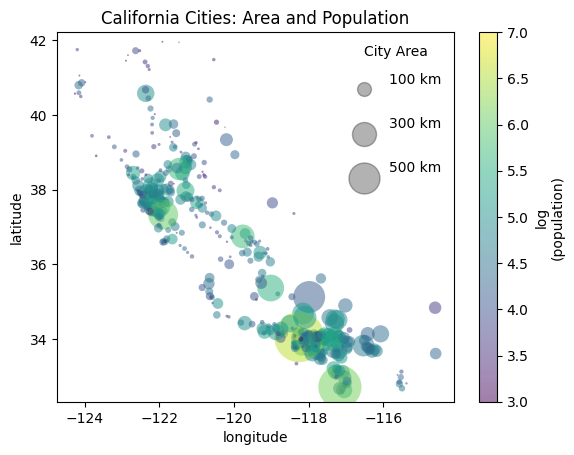

In [ ]:
# Path to file /content/drive/MyDrive/AIDS1 /notebooks/data/california_cities.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
cities = pd.read_csv("/content/california_cities.csv")

# Extract the data we're interested in
lat, lon = cities['latd'], cities['longd']
population, area = cities['population_total'], cities['area_total_km2']

# Scatter the points, using size and color but no label
plt.scatter(lon, lat, label=None,
            c=np.log10(population), cmap='viridis',
            s=area, linewidth=0, alpha=0.5)
plt.axis('equal')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.colorbar(label='log\n(population)')
plt.clim(3, 7)

# Here we create a legend:
# we'll plot empty lists with the desired size and label
for area in [100, 300, 500]:
    plt.scatter([], [], c='k', alpha=0.3, s=area,
                label=str(area) + ' km\n')
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title='City Area')

plt.title('California Cities: Area and Population');

**Multiple Subplots**

Sometimes it is helpful to compare different views of data side by side. Matplotlib has the concept of `subplots` : groups of smaller axes that can exist together within a single figure.

These subplots might be insets, grids of plots, or other more complicated layouts.

In [ ]:
plt.style.use('seaborn-v0_8-white')
import numpy as np

**`plt.axes`: Subplots by Hand (Coding)**

The most basic method of creating an axes is to use the `plt.axes` function. By default this creates a standard axes object that fills the entire figure.

`plt.axes` also takes an optional argument that is a list of four numbers in the figure coordinate system. These numbers represent `[left, bottom, width, height]` in the figure coordinate system, which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure.

For example, we might create an inset axes at the top-right corner of another axes by setting the x and y position to 0.65 (that is, starting at 65% of the width and 65% of the height of the figure) and the x and y extents to 0.2 (that is, the size of the axes is 20% of the width and 20% of the height of the figure):

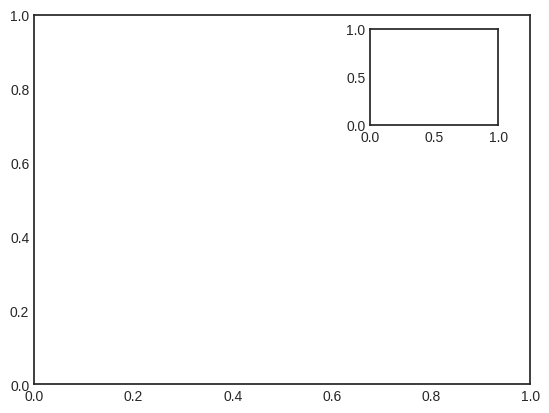

In [ ]:
ax1 = plt.axes()  # standard axes
ax2 = plt.axes([0.650, 0.650, 0.2, 0.2]) #inset axes

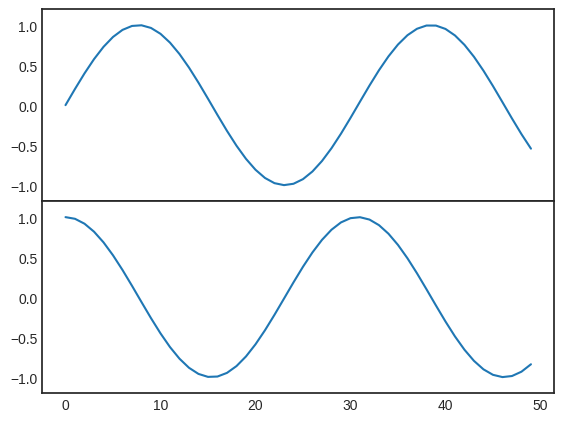

In [ ]:
#creating subplot using fig.add_axes
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2))
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2))

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x));

**`plt.subplot`: Simple Grids of Subplots**

Aligned columns or rows of subplots are a common-enough need that Matplotlib has several convenience routines that make them easy to create.

The lowest level of these is `plt.subplot()`, which creates a single subplot within a grid.

As you can see, this command takes three integer arguments—the number of rows, the number of columns, and the index of the plot to be created in this scheme, which runs from the upper left to the bottom right:

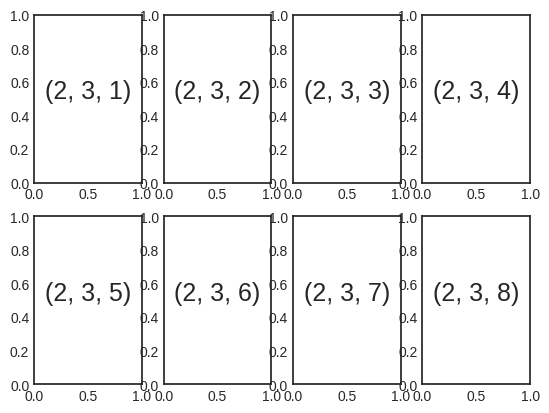

In [ ]:
for i in range(1, 9):
    plt.subplot(2, 4, i)
    plt.text(0.5, 0.5, str((2, 3, i)),
             fontsize=18, ha='center')

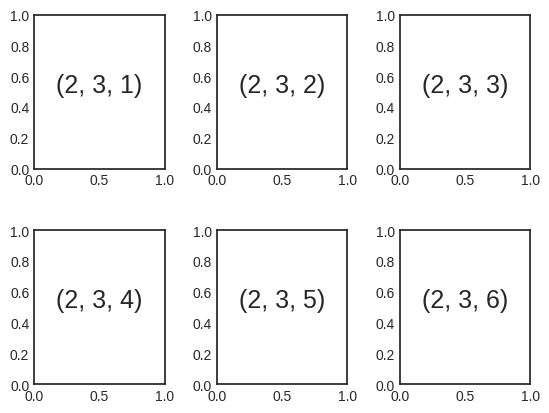

In [ ]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

**`plt.subplots`: The Whole Grid in One Go**

The approach just described can become quite tedious when creating a large grid of subplots, especially if you'd like to hide the x- and y-axis labels on the inner plots. For this purpose, plt.subplots() is the easier tool to use (note the s at the end of subplots). Rather than creating a single subplot, this function creates a full grid of subplots in a single line, returning them in a NumPy array. The arguments are the number of rows and number of columns, along with optional keywords sharex and sharey, which allow you to specify the relationships between different axes.

Here we'll create a 2 x 3 grid of subplots, where all axes in the same row share their y-axis scale, and all axes in the same column share their x-axis scale:

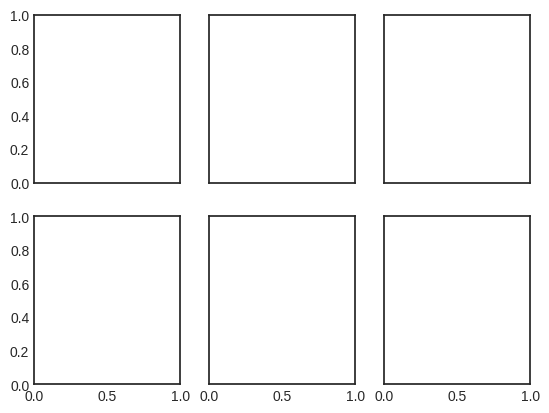

In [ ]:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')

Note that by specifying sharex and sharey, we've automatically removed inner labels on the grid to make the plot cleaner.

The resulting grid of axes instances is returned within a NumPy array, allowing for convenient specification of the desired axes using standard array indexing notation:

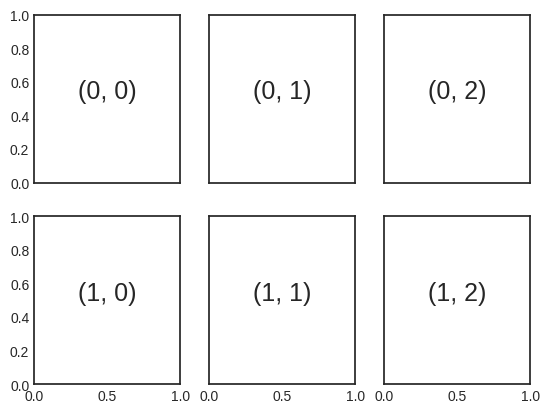

In [ ]:
# axes are in a two-dimensional array, indexed by [row, col]
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=18, ha='center')
fig

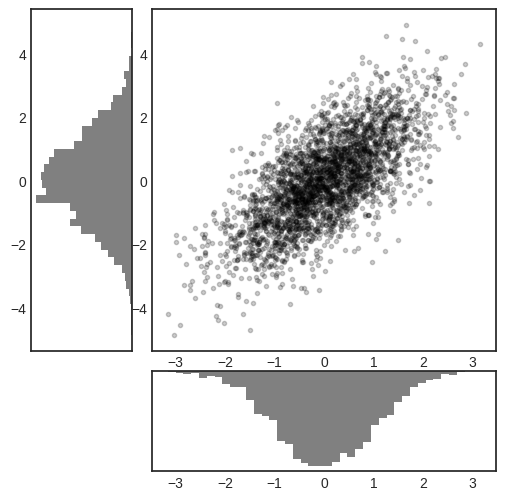

In [ ]:
# An example of Flexible grid arrangement
# Create some normally distributed data
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 3000).T

# Set up the axes with gridspec
fig = plt.figure(figsize=(6, 6))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
main_ax = fig.add_subplot(grid[:-1, 1:])
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax)
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax)

# scatter points on the main axes
main_ax.plot(x, y, 'ok', markersize=3, alpha=0.2)

# histogram on the attached axes
x_hist.hist(x, 40, histtype='stepfilled',
            orientation='vertical', color='gray')
x_hist.invert_yaxis()

y_hist.hist(y, 40, histtype='stepfilled',
            orientation='horizontal', color='gray')
y_hist.invert_xaxis()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# An example of Complex Plotting
births = pd.read_csv("/content/births.csv")

quartiles = np.percentile(births['births'], [25, 50, 75])
mu, sig = quartiles[1], 0.74 * (quartiles[2] - quartiles[0])
births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')

births['day'] = births['day'].astype(int)

births.index = pd.to_datetime(10000 * births.year +
                              100 * births.month +
                              births.day, format='%Y%m%d')
births_by_date = births.pivot_table('births',
                                    [births.index.month, births.index.day])
births_by_date.index = [datetime(2012, month, day)
                        for (month, day) in births_by_date.index]

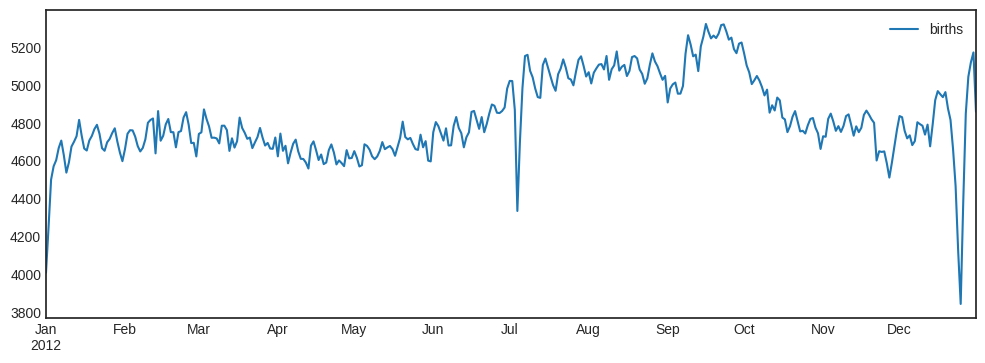

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax);

**Boxplot**

A Box Plot is also known as Whisker plot is created to display the summary of the set of data values having properties like minimum, first quartile, median, third quartile and maximum.

In the box plot, a box is created from the first quartile to the third quartile, a vertical line is also there which goes through the box at the median. Here x-axis denotes the data to be plotted while the y-axis shows the frequency distribution.

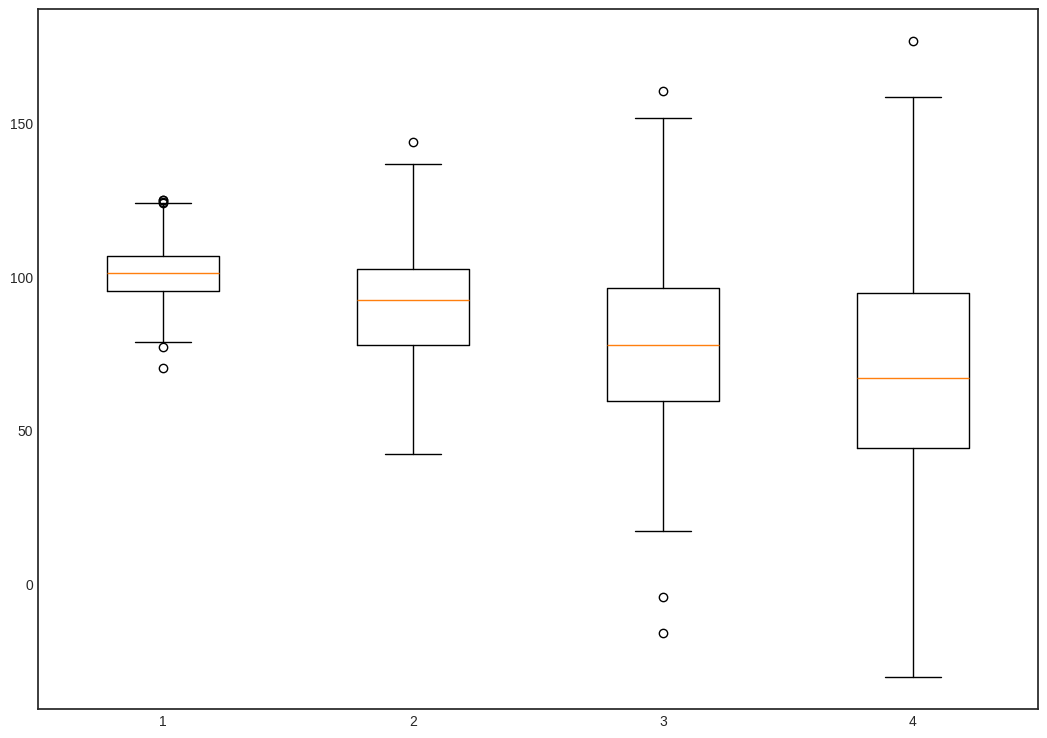

In [ ]:
#Exmple of Box plot for some random data sets
# Import libraries
import matplotlib.pyplot as plt
import numpy as np


# Creating dataset
np.random.seed(10)

data_1 = np.random.normal(100, 10, 200)
data_2 = np.random.normal(90, 20, 200)
data_3 = np.random.normal(80, 30, 200)
data_4 = np.random.normal(70, 40, 200)
data = [data_1, data_2, data_3, data_4]

fig = plt.figure(figsize =(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])

# Creating plot
bp = ax.boxplot(data)

# show plot
plt.show()

Questions:

1.What is boxplot ?

Ans : A boxplot, also known as a box-and-whisker plot, is a graphical representation used to display the distribution of numerical data based on a five-number summary: minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum. The rectangular box represents the interquartile range (IQR), which contains the middle 50% of the data, while a line inside the box indicates the median value. The “whiskers” extend from the box to show the minimum and maximum values, excluding outliers. Any data points that fall significantly above or below the range (usually beyond 1.5 × IQR) are plotted separately as outliers. Boxplots are useful for understanding the spread, central tendency, skewness, and variability of data, and they are especially helpful when comparing multiple datasets.

2.What information do we get from a box plot?

Ans : A box plot provides several important pieces of information about a dataset. It shows the central tendency of the data through the median (the line inside the box), which indicates the middle value. It displays the spread or variability of the data using the interquartile range (IQR), represented by the length of the box (from Q1 to Q3), which contains the middle 50% of the observations. The whiskers show the overall range of the data (excluding outliers), helping us understand how far the values extend. A box plot also reveals the presence of outliers, which appear as individual points beyond the whiskers. Additionally, by observing the position of the median and the lengths of the whiskers, we can identify the skewness of the data (whether it is symmetric, positively skewed, or negatively skewed). Overall, a box plot gives a quick summary of distribution, spread, center, and unusual values in a dataset.

3.How is minimum and maximum whisker's marked in a box plot ?

Ans : In a box plot, the minimum and maximum whiskers are marked using horizontal lines (called whisker caps) at the ends of vertical lines extending from the box.

The whiskers start from:

Q1 (first quartile) and extend downward to the minimum value

Q3 (third quartile) and extend upward to the maximum value

However, in most standard box plots, the whiskers do not always represent the absolute minimum and maximum values. Instead, they extend to the smallest and largest values that are within 1.5 × IQR from the quartiles.

The rule used is:

IQR=Q3−Q1

Whiskers extend to: IQR=Q3−Q1

LowerLimit=Q1−1.5×IQR

UpperLimit=Q3+1.5×IQR

Any values beyond these limits are marked separately as outliers (usually dots or circles).

4.How to we identify that some points in data are outliers by viewing the box plot?

Ans : We can identify outliers in a box plot by looking for individual points plotted outside the whiskers. In a standard box plot, the whiskers extend only up to a certain limit based on the interquartile range (IQR). Any data values that lie beyond this limit are considered outliers and are shown as separate dots or small circles.

The interquartile range is calculated as:

IQR=Q3−Q1

A data point is considered an outlier if it is:

LessthanQ1−1.5×IQR

or

GreaterthanQ3+1.5×IQR

In the box plot:

Values within this range are covered by the whiskers.

Values outside this range are plotted separately as points.

Therefore, by simply observing any points beyond the whiskers, we can easily identify outliers in the dataset.

5.Read a data file from your drive and for all numeric columns plot boxplot.

Ans : Program: Read a data file from Google Drive and plot boxplot for all numeric columns

Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 2: Import Required Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Step 3: Read the CSV File from Drive

In [ ]:
file_path = '/content/drive/MyDrive/weather.csv'
df = pd.read_csv(file_path)

Example:

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/weather.csv')

Step 4: Plot Boxplot for All Numeric Columns

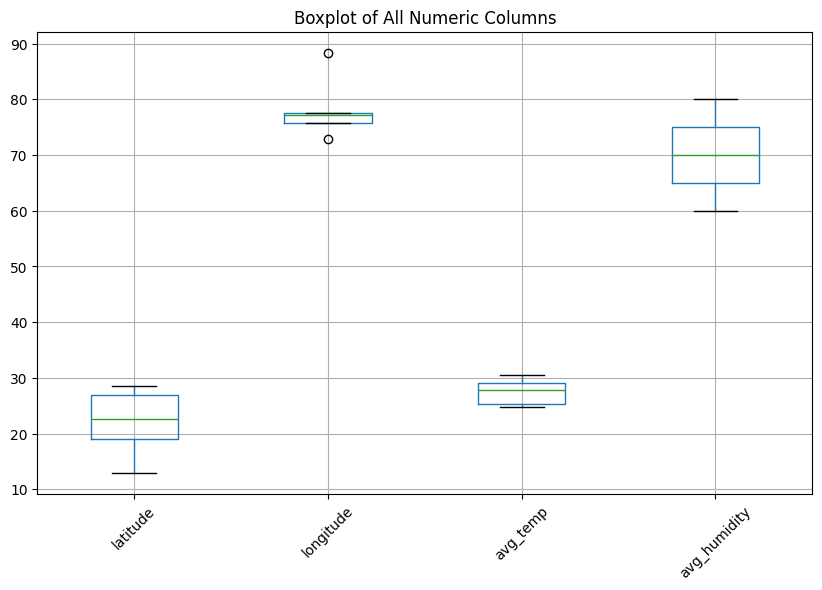

In [ ]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of All Numeric Columns")
plt.show()

Explanation

df.boxplot() automatically selects only numeric columns.

Each numeric column will have one boxplot.

Outliers will appear as dots.

X-axis shows column names.

Y-axis shows data values.

**Conclusion**


Thus we have learned about basics of Contour plots, Histograms, Box plots.